In [50]:
import pandas as pd
import numpy as np
import math
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.gridspec as gridspec

def addColumns(data):
    #Add Responders vs Non Responder:
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])

    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'

    #Add log neoantigen columns:
    neoantigen_cols = ["nonsyn_muts", "clonal_muts","subclonal_muts","total_neoantigens"]
    for col in neoantigen_cols:
        log_col = f"log_{col}"
        log_values = []
        for x in data[col]:
            if x < 0:
                warnings.warn(
                    f"There is abnormal value in the {col} column.",
                    DeprecationWarning,
                )
                log_values.append(math.log((0+1e-9), 10))
            else:
                log_values.append(math.log((x+1e-9), 10))
        data[log_col] = log_values
    return data

def cluster_features(data, method = "ward"):
    corrmat = data.corr()
    # 2. Replace NaN/infinite with 0 (or another value as needed)
    if corrmat.isnull().values.any() or np.isinf(corrmat.values).any():
        print("Warning: NaNs/Infs found in correlation matrix, filling with 0.")
        corrmat = corrmat.fillna(0)
        corrmat.replace([np.inf, -np.inf], 0, inplace=True)
    
    Z = linkage(corrmat, method=method)
    plt.ioff()

    dendrogram_output = dendrogram(
        Z, 
        leaf_rotation=90, 
        leaf_font_size=6
    )
    
    order = [int(s) for s in dendrogram_output['ivl']]
    plt.close()
    return Z, order, corrmat

def draw_clustermap(
    corrmatrix,
    dataset,
    order,
    feature_groups,
    color_map,
    figsize=(6, 6),
    is_large=True
):
    if len(order) != len(corrmatrix.index):
        raise ValueError(
            f"Length of 'order' ({len(order)}) does not match corrmatrix shape ({corrmatrix.shape})"
        )

    # Order features
    ordered_features = corrmatrix.index[order]
    corr_sub = corrmatrix.loc[ordered_features, ordered_features]

    # Build annotation colors
    col_colors = []
    for feat in ordered_features:
        assigned = False
        for fg, members in feature_groups.items():
            if feat in members:
                col_colors.append(color_map.get(fg, color_map["Other"]))
                assigned = True
                break
        if not assigned:
            col_colors.append(color_map["Other"])

    # Draw clustermap
    cg = sns.clustermap(
        corr_sub,
        cmap="coolwarm",
        center=0,
        row_colors=col_colors,
        col_colors=col_colors,
        linewidths=0,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        vmin = -1,
        vmax = 1,
    )

    # Title (correct way)
    title_color = DATASET_COLORS.get(dataset, "black")
    cg.fig.suptitle(
        dataset,
        fontsize=18 if is_large else 18,
        fontweight="bold",
        color=title_color,
        y=1.02
    )

    # Tick labels
    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(),
        rotation=0,
        fontsize=12 if is_large else 12
    )

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        rotation=90,
        fontsize=12 if is_large else 12
    )
    if not is_large:
        cg.cax.set_visible(False)
        
    cg.cax.set_aspect(20) 
    cg.cax.set_position([0.92, 0.25, 0.02, 0.5])
    cg.cax.set_yticks([-1, 0, 1])
    cg.cax.tick_params(labelsize=12)
        
    
    plt.show()
    return cg

In [51]:
seed = 0
syn_datas = ["original_data",f"avatarsk5_{seed}", f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
dataset_dict = {}
for syn_data in syn_datas:
    print(f"-----{syn_data}-----")
    df = pd.read_csv(f"../Melanoma/Data/{syn_data}.csv",index_col = 0)
    processed_df = addColumns(df)
    dataset_dict[syn_data] = processed_df

-----original_data-----
-----avatarsk5_0-----
-----avatarsk10_0-----
-----ctgan_0-----
-----gaussiancopula_0-----
-----synthpop_0-----
-----tvae_0-----


In [52]:
comparators = ['log_nonsyn_muts', 'log_clonal_muts', 'heterogeneity','purity','ploidy',
             'CNA_prop', 'log_total_neoantigens','HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
            'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 'HLA-DRB5',
            'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'TAP1', 'TAP2', 'B2M', 'MHCI_Amp','TAP2_Amp','Tx_Start_LDH']

rename_map_short = {
    # Mutation burden
    'log_nonsyn_muts': 'Nonsyn Mut Burden',
    'log_clonal_muts': 'Clonal Mut Burden',

    # Tumor evolution
    'heterogeneity': 'Tumor Heterogeneity',
    'purity': 'Tumor Purity',
    'ploidy': 'Tumor Ploidy',

    # Copy number
    'CNA_prop': 'CNA Burden',

    # Neoantigen
    'log_total_neoantigens': 'Neoantigen Load',

    # HLA class II
    'HLA-DMA': 'HLA-DMA',
    'HLA-DMB': 'HLA-DMB',
    'HLA-DOA': 'HLA-DOA',
    'HLA-DOB': 'HLA-DOB',
    'HLA-DPA1': 'HLA-DPA1',
    'HLA-DPB1': 'HLA-DPB1',
    'HLA-DQA1': 'HLA-DQA1',
    'HLA-DQA2': 'HLA-DQA2',
    'HLA-DQB1': 'HLA-DQB1',
    'HLA-DQB2': 'HLA-DQB2',
    'HLA-DRA': 'HLA-DRA',
    'HLA-DRB1': 'HLA-DRB1',
    'HLA-DRB5': 'HLA-DRB5',

    # Antigen presentation – MHC I
    'HLA-A': 'HLA-A',
    'HLA-B': 'HLA-B',
    'HLA-C': 'HLA-C',
    'HLA-E': 'HLA-E',
    'TAP1': 'TAP1',
    'TAP2': 'TAP2',
    'B2M': 'B2M',

    # Amplification
    'MHCI_Amp': 'MHC-I Amp',
    'TAP2_Amp': 'TAP2 Amp',

    # Clinical
    'Tx_Start_LDH': 'Baseline LDH'
}

new_dataset = {}
for dataset, df in dataset_dict.items():
    extracted_df = df[comparators]
    rename_df = extracted_df.rename(columns = rename_map_short)
    new_dataset[dataset] = rename_df


In [53]:
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5":  "#66c2a5",  # greenish
    "Avatars K10": "#fc8d62",  # orange
    "CTGAN":  "#8da0cb",  # blue
    "Gaussian Copula":   "#e78ac3",  # pink
    "Synthpop":  "#a6d854",  # lime
    "TVAE":  "#ffd92f",  # yellow
}


color_map = {
    "MHC1": "#1f77b4",    # blue
    "MHC2": "#ff7f0e",    # orange
    "Other": "#d3d3d3"    # light gray
}
feature_groups = {"MHC1": ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M'],
                 "MHC2": [
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
    'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
    'HLA-DRB5'
]}

TARGET_ASPECT = 1
plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'axes.edgecolor': '#333333',
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'xtick.top': False,
    'ytick.right': False,
    # 'font.family': 'sans-serif'
})

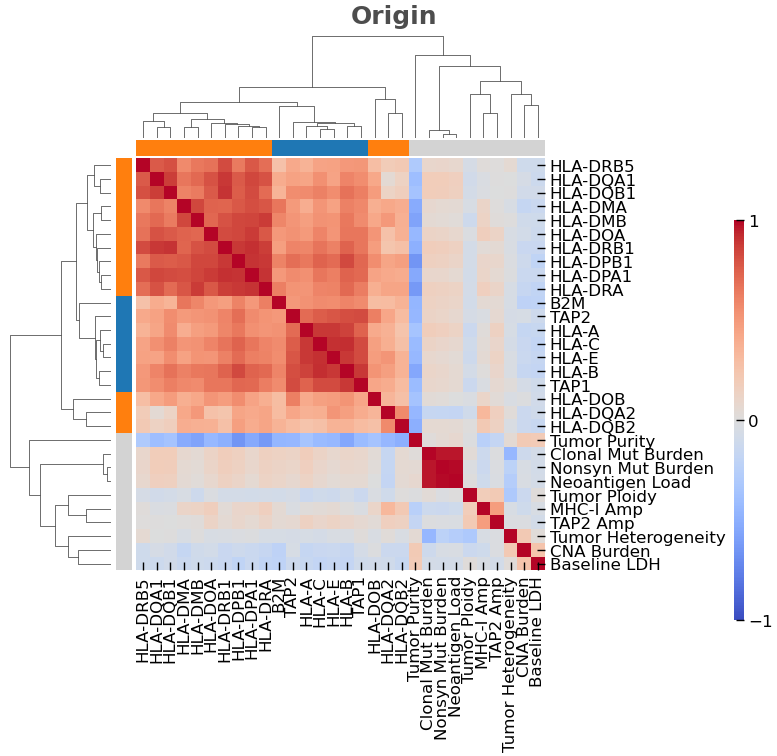

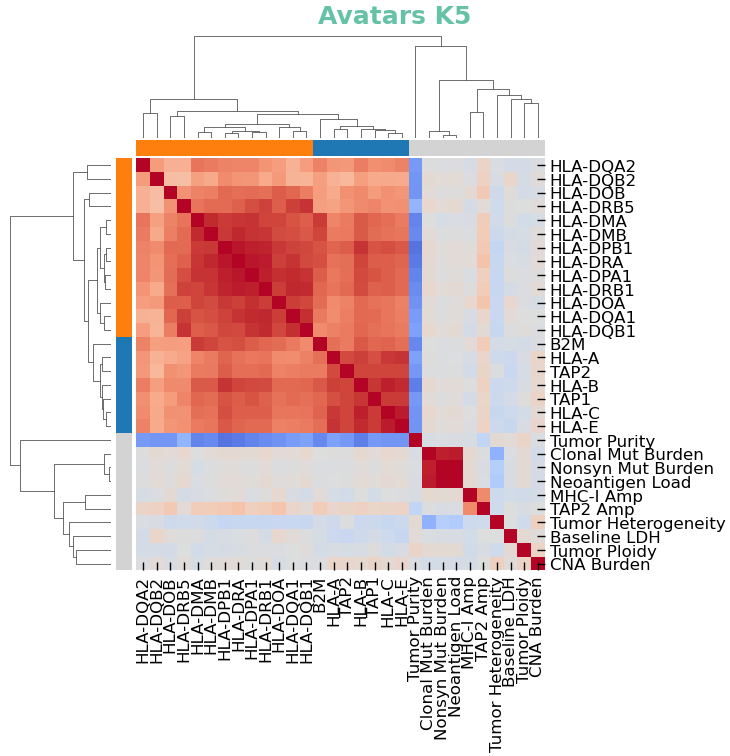

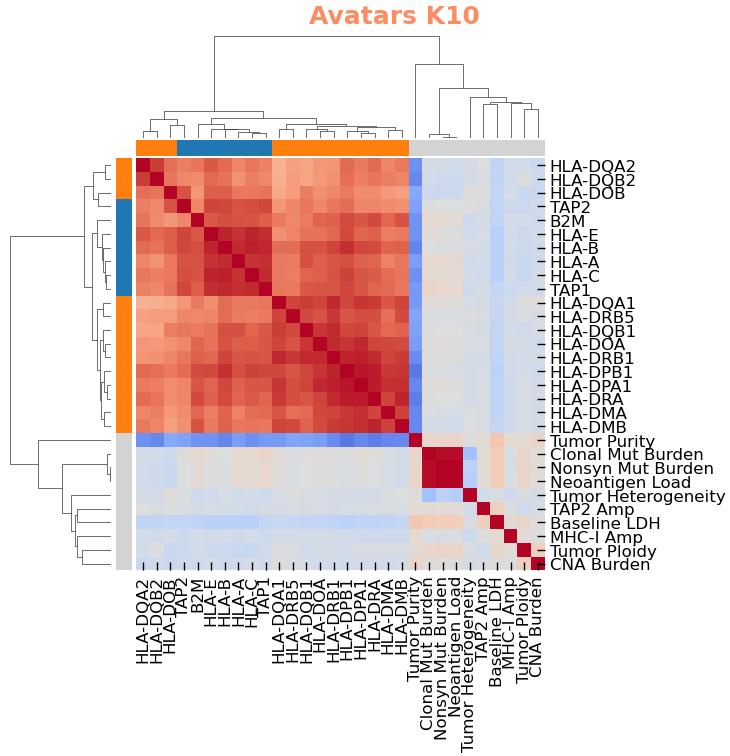

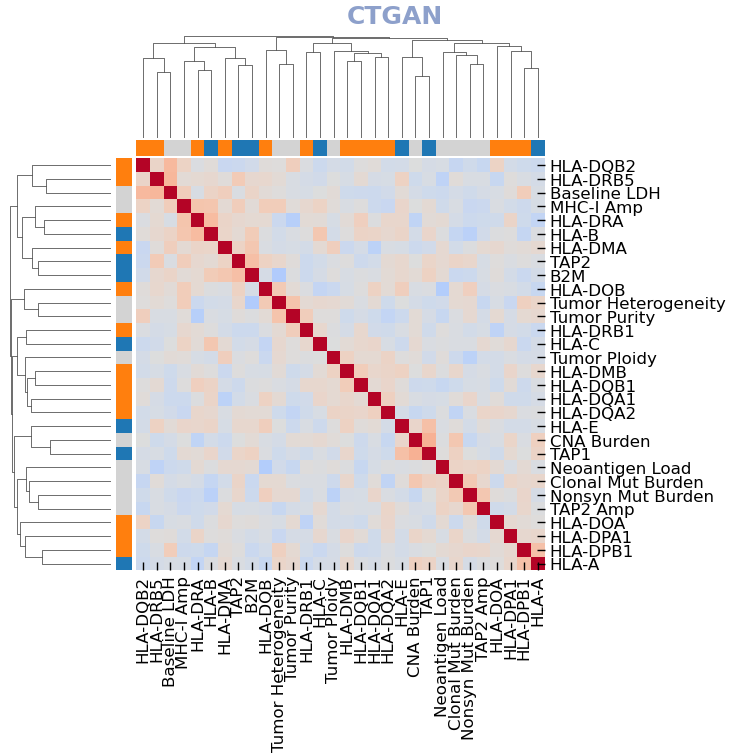

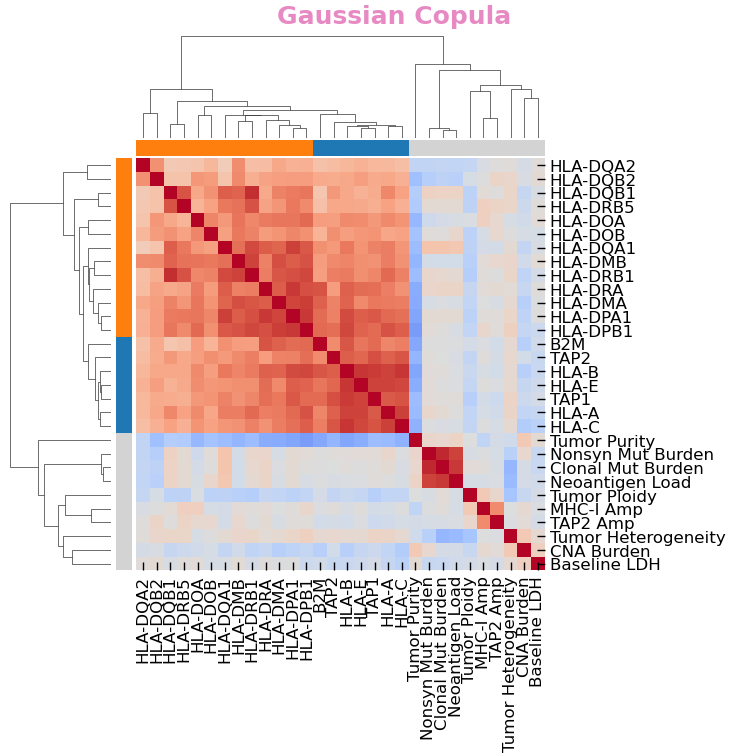

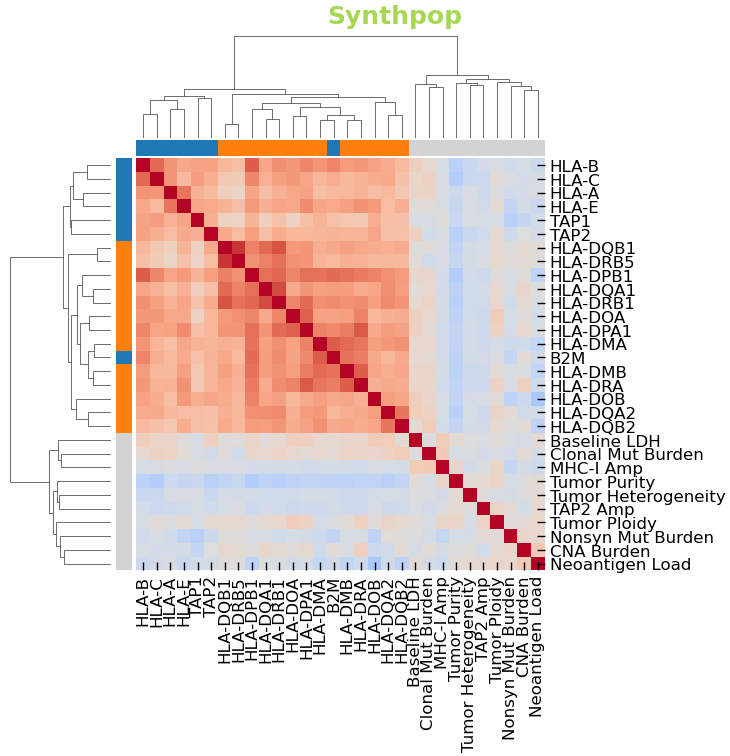

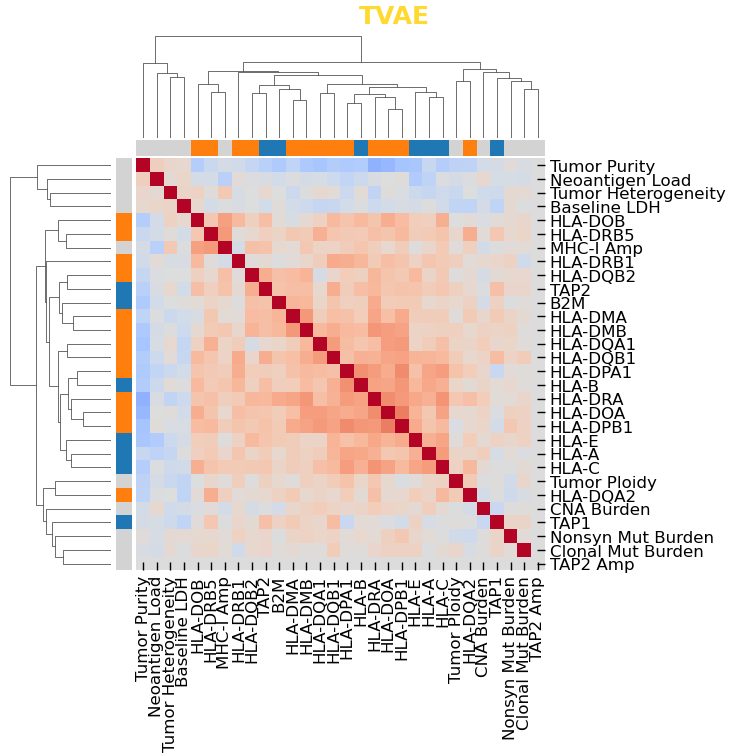

In [54]:
datasets = ['Origin', 'Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
for i, key in enumerate(new_dataset.keys()):
    Z, order, corrmat = cluster_features(new_dataset[key], "ward")
    dataset = datasets[i]
    if key == 'original_data' :
        cg = draw_clustermap(corrmat, dataset, order, feature_groups, color_map, figsize = (8,8), is_large = True)
        # cg.fig.savefig(f'DemoClusterMap/{key}.pdf', dpi=300, bbox_inches="tight")
    else:
        cg = draw_clustermap(corrmat, dataset, order, feature_groups, color_map, figsize = (8,8), is_large = False)
    
    # cg.fig.savefig(f'DemoClusterMap/{key}.pdf', dpi=300, bbox_inches="tight")
    cg.fig.savefig(f'DemoClusterMap/{key}.png', dpi=300, bbox_inches="tight")

/tmp/ipykernel_416223/3235833438.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


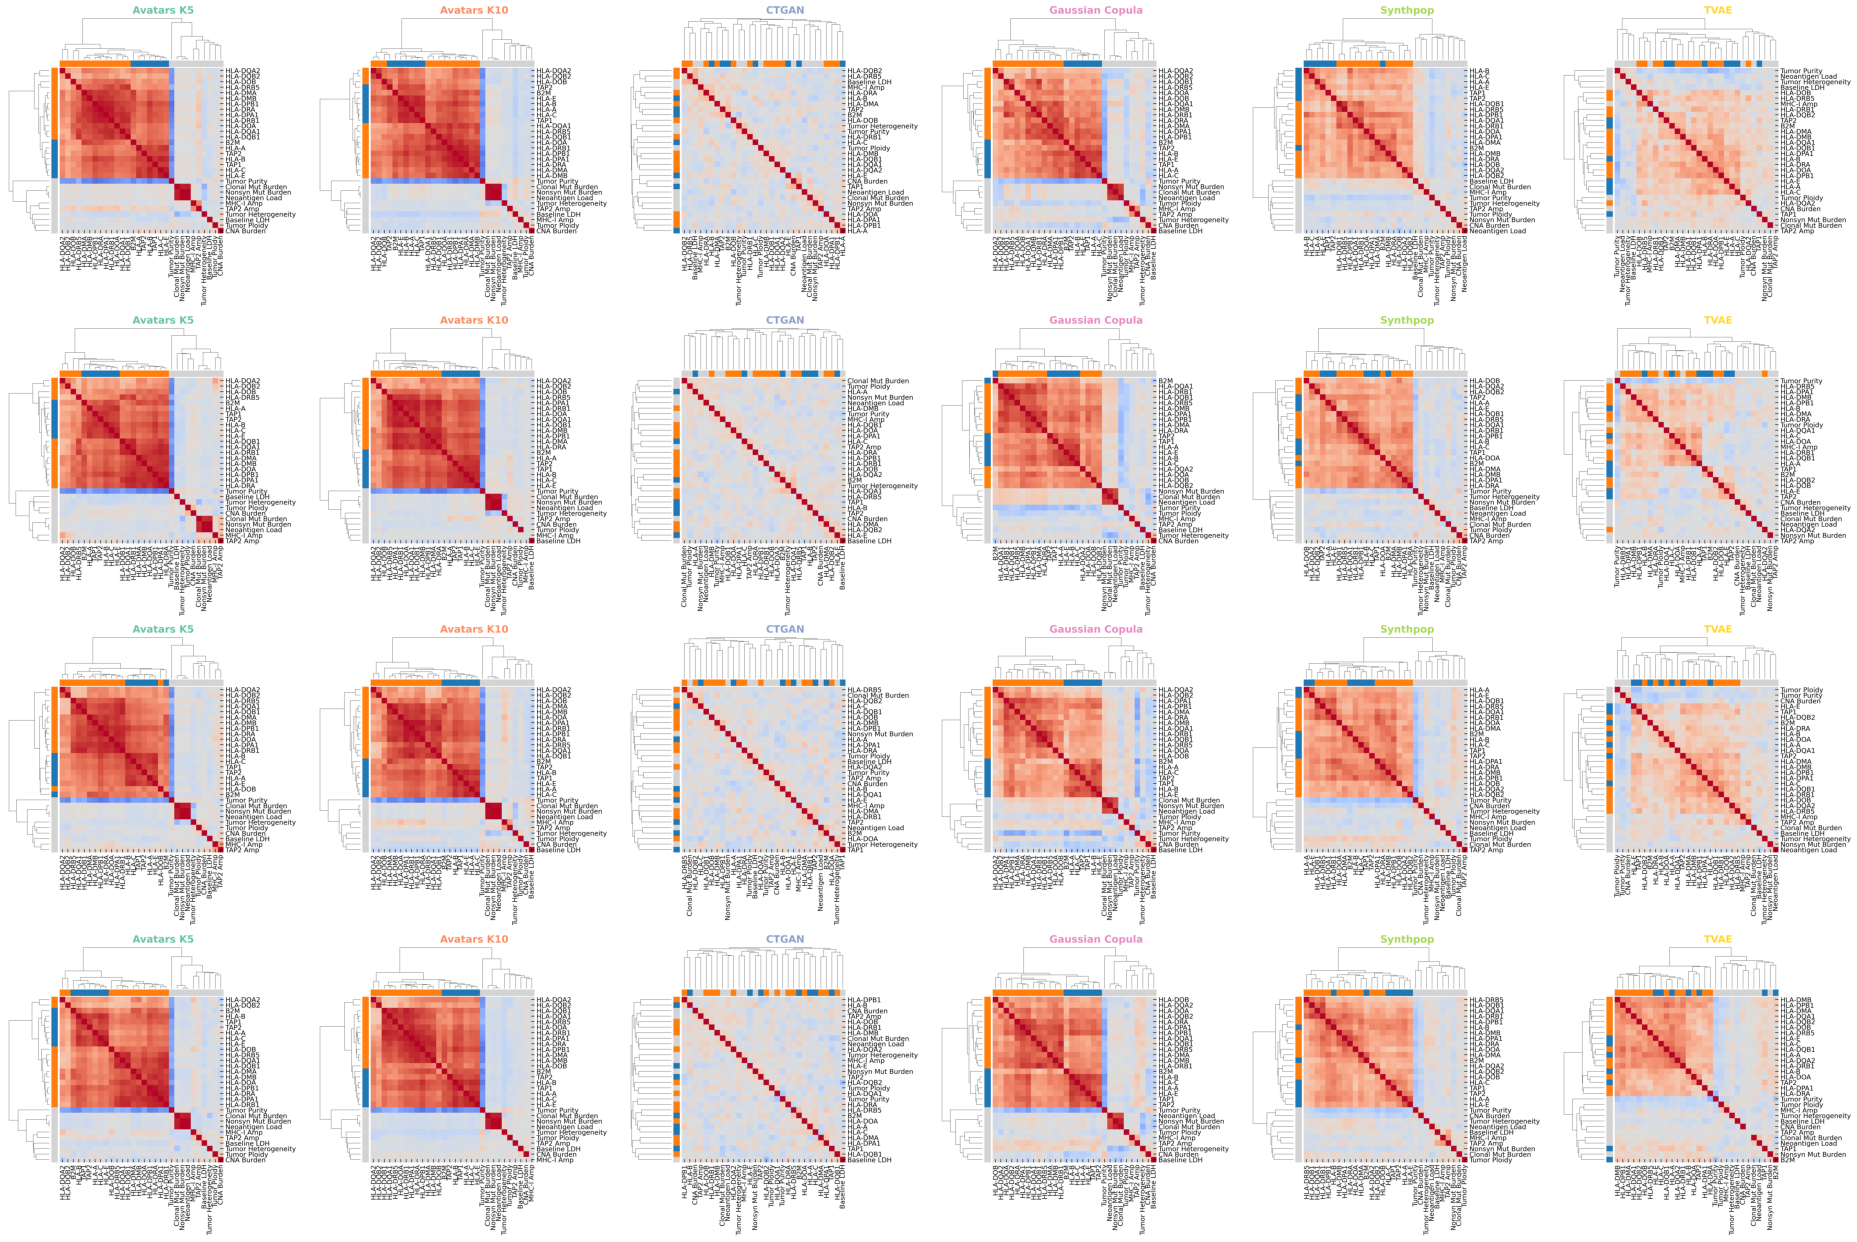

In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import gridspec

seeds = [0, 1, 2, 3]
methods = [
    "avatarsk5",
    "avatarsk10",
    "ctgan",
    "gaussiancopula",
    "synthpop",
    "tvae"
]

fig = plt.figure(figsize=(24, 16))  # rộng hơn vì 6 cột
gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    wspace=0.02,
    hspace=0.02
)

def show_img(ax, path):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")

for row, seed in enumerate(seeds):
    for col, method in enumerate(methods):
        path = f"DemoClusterMap/{method}_{seed}.png"
        ax = fig.add_subplot(gs[row, col])
        show_img(ax, path)

plt.tight_layout()
fig.savefig("DemoClusterMap/Combined_24_images_6x4.pdf", dpi=300, bbox_inches="tight")
fig.savefig("DemoClusterMap/Combined_24_images_6x4.png", dpi=300, bbox_inches="tight")
plt.show()